In [1]:
from openai import OpenAI
client = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio", timeout=60)


{'model': 'olmocr',
 'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'Attached is one page of a document that you must process. Just return the plain text representation of this document as if you were reading it naturally. Convert equations to LateX and tables to HTML.\nIf there are any figures or charts, label them with the following markdown syntax ![Alt text describing the contents of the figure](page_startx_starty_width_height.png)\nReturn your output as markdown, with a front matter section on top specifying values for the primary_language, is_rotation_valid, rotation_correction, is_table, and is_diagram parameters.'},
    {'type': 'image_url',
     'image_url': {'url': ''}}]}],
 'max_tokens': 8000,
 'temperature': 0.0}
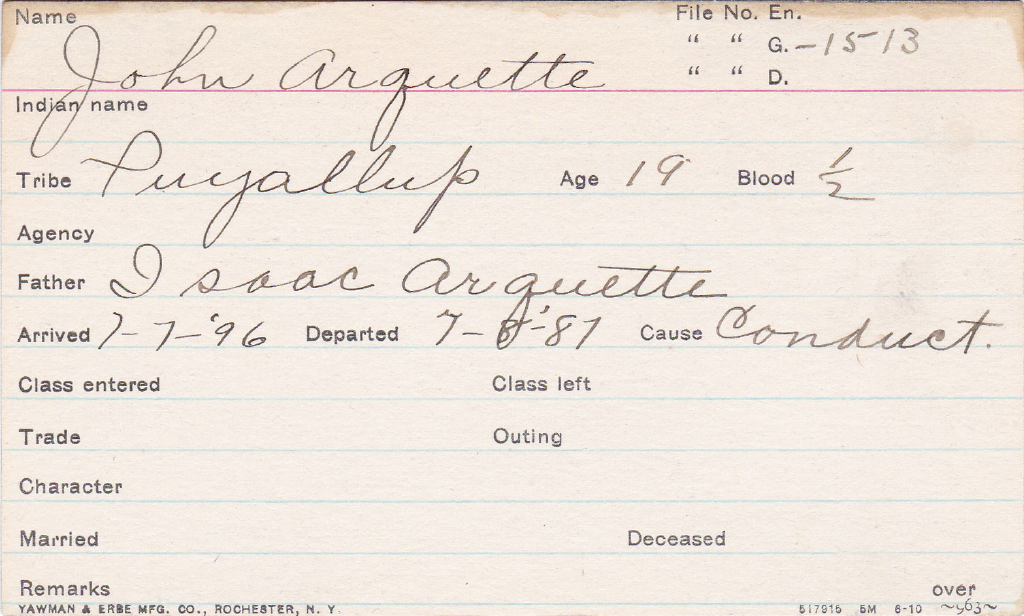

In [5]:
from pprint import pprint
from olmocr.pipeline import build_page_query

query = await build_page_query("sample.pdf", page=1,target_longest_image_dim=1024)

query

In [6]:
query['model'] = 'allenai_olmocr-7b-0225-preview'
response = client.chat.completions.create(**query)

print(response.choices[0].message.content)


INFO:httpx:HTTP Request: POST http://localhost:1234/v1/chat/completions "HTTP/1.1 200 OK"


{"primary_language":"en","is_rotation_valid":true,"rotation_correction":0,"is_table":false,"is_diagram":false,"front_matter":null,"natural_text":"Name: John Arquette\nIndian name: Puyallup\nAge: 19\nBlood: ½\nAgency: Isaac Arquette\nArrived: 7-7-96\nDeparted: 7-8-81\nCause of Death: Conduct\nClass entered: Class left: Outing\nTrade:\nCharacter:\nMarried:\nRemarks: Yawman & Erbe Mfg. Co., Rochester, N.Y."}


In [17]:
import json
from pathlib import Path
from tqdm.notebook import trange

from pypdf import PdfReader
from olmocr.pipeline import build_page_query, build_dolma_document, PageResult
from olmocr.prompts import PageResponse

async def process_page(filename, page_num):
    query = await build_page_query(filename,
                                   page=page_num,
                                   target_longest_image_dim=1024)
    query['model'] = 'allenai_olmocr-7b-0225-preview'
    response = client.chat.completions.create(**query)
    model_obj = json.loads(response.choices[0].message.content)
    print(model_obj.keys())
    
    # Filter to only expected PageResponse fields
    expected_fields = {'primary_language', 'is_rotation_valid', 'rotation_correction', 'is_table', 'is_diagram', 'natural_text'}
    filtered_obj = {k: v for k, v in model_obj.items() if k in expected_fields}
    page_response = PageResponse(**filtered_obj)
    
    
    return PageResult(
        filename,
        page_num,
        page_response,
        input_tokens=response.usage.prompt_tokens,
        output_tokens=response.usage.completion_tokens,
        is_valid=True,
        is_fallback=False,
    )
    
filename = "sample.pdf"

reader = PdfReader(filename)
num_pages = reader.get_num_pages()
results = []

for page_num in trange(1, num_pages + 1):
    result = await process_page(filename, page_num)
    results.append(result)

  0%|          | 0/1 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST http://localhost:1234/v1/chat/completions "HTTP/1.1 200 OK"


dict_keys(['primary_language', 'is_rotation_valid', 'rotation_correction', 'is_table', 'is_diagram', 'front_matter', 'natural_text'])


In [20]:
text = '\n'.join([result.response.natural_text for result in results])
print(text)

Name: John Arquette
Indian name: Puyallup
Age: 19
Blood: ½
Agency: Isaac Arquette
Arrived: 7-7-96
Departed: 7-8-81
Cause of Death: Conduct
Class entered: Class left: Outing
Trade:
Character:
Married:
Remarks: Yawman & Erbe Mfg. Co., Rochester, N.Y.


In [21]:
output_folder = Path("workspace/results")
output_folder.mkdir(exist_ok=True, parents=True)

doc = build_dolma_document(filename, results)
dolma_path = output_folder.joinpath(filename).with_suffix(".results.jsonl")
dolma_path.write_text(json.dumps(doc) + "\n")

751

In [22]:
!python -m olmocr.viewer.dolmaviewer workspace/results/*.jsonl

Processing documents: 100%|███████████████████████| 1/1 [00:01<00:00,  1.76s/it]
Output HTML-viewable pages to directory: dolma_previews


In [23]:
!open dolma_previews/sample_pdf.html
